# StairMaster Step Counter — Multi-Algorithm, Multi-Backend Comparison

Profile camera + real leg occlusion breaks the naive dual-leg peak-detection approach
(your window 1 test: ground truth 7/7, algorithm returned 9/16 with MediaPipe and 20/20
with YOLO). This notebook keeps the original methods and adds three new ones so you can
compare all of them, on both MediaPipe and YOLO Pose, side by side.

**Methods included, per backend, per leg:**

1. **Ankle peak detection** (original) — local maxima in smoothed ankle-y signal
2. **Ankle zero-crossing** (new) — counts upward crossings of the signal's mean; more
   tolerant of noisy/occluded peaks than requiring a clean local maximum
3. **Autocorrelation** (original, bug-fixed) — estimates dominant step period from the
   whole signal at once
4. **Near-leg-only + zero-crossing** (new) — picks whichever leg the camera tracks more
   reliably (higher average confidence = less occluded), counts steps only on that leg
   via zero-crossing, and assumes the far leg matches it 1:1 (StairMaster pedals are a
   rigid mechanical linkage, so this is a physically reasonable assumption)
5. **Knee-angle peak detection** (new) — same peak-detection logic, but on the knee joint
   angle instead of ankle position; angle can be more robust than raw position under
   partial occlusion since it uses three points, not one
6. **Knee-angle zero-crossing** (new) — zero-crossing counting on the knee-angle signal

Also raises the confidence threshold (0.5 -> 0.7) and widens smoothing/min-interval
defaults to match a realistic ~20-30 steps/min cadence rather than the old defaults
that allowed up to 240 steps/min through unfiltered.

## 0. Setup

In [1]:
# Uncomment on first run
# !pip install mediapipe==0.10.14 opencv-python-headless scipy numpy matplotlib ultralytics --quiet

import os
os.environ["GLOG_minloglevel"] = "2"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import warnings
warnings.filterwarnings("ignore")

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks, correlate
import mediapipe as mp
from ultralytics import YOLO

mp_pose = mp.solutions.pose
yolo_model = YOLO("yolov8n-pose.pt")

print("MediaPipe:", mp.__version__)
print("YOLO pose model loaded.")

MediaPipe: 0.10.14
YOLO pose model loaded.


## 1. Configuration

In [ ]:
VIDEO_PATH = "0901.mov"

WINDOW_LENGTH_SEC = 20
NUM_WINDOWS = 3
MANUAL_WINDOWS = None   # e.g. [(10, 30), (606, 626), (1203, 1223)] to reuse your exact windows

# Tuned for a realistic StairMaster cadence (roughly 15-40 steps/min per leg).
# 0.6s min interval = caps at 100 steps/min per leg, well above realistic pace,
# but still rejects the double/triple-counted noise seen at 0.25s.
MIN_STEP_INTERVAL_SEC = 1.3

# Wider smoothing window (was 9 frames / ~0.3s; now ~0.8s at 30fps) so occlusion jitter
# gets filtered out instead of passing through as fake peaks.
SAVGOL_WINDOW = 25
SAVGOL_POLYORDER = 2

# Landmarks below this confidence are masked out entirely (was 0.5).
# Raised because occluded legs were still scoring above 0.5 while tracking noise.
CONFIDENCE_THRESHOLD = 0.7

In [3]:
def get_video_duration(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open video: {video_path}")
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    n_frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    cap.release()
    return n_frames / fps, fps


def fmt_time(sec):
    m, s = divmod(int(sec), 60)
    return f"{m:02d}:{s:02d}"


def build_windows(duration_sec, window_len, num_windows, manual=None):
    if manual is not None:
        return manual
    if duration_sec <= window_len:
        return [(0, duration_sec)]
    margin = window_len / 2
    usable_start = margin
    usable_end = duration_sec - margin - window_len
    if num_windows == 1 or usable_end <= usable_start:
        starts = [max(0, (duration_sec - window_len) / 2)]
    else:
        starts = np.linspace(usable_start, usable_end, num_windows)
    return [(round(s, 1), round(s + window_len, 1)) for s in starts]


duration_sec, source_fps = get_video_duration(VIDEO_PATH)
windows = build_windows(duration_sec, WINDOW_LENGTH_SEC, NUM_WINDOWS, MANUAL_WINDOWS)

print(f"Video duration: {fmt_time(duration_sec)} ({duration_sec:.1f}s), source fps: {source_fps:.1f}\n")
print("WINDOWS TO VALIDATE:")
for i, (start, end) in enumerate(windows):
    print(f"  Window {i+1}: {fmt_time(start)} - {fmt_time(end)}   ({start}s to {end}s)")

Video duration: 20:33 (1233.5s), source fps: 30.0

WINDOWS TO VALIDATE:
  Window 1: 00:10 - 00:30   (10.0s to 30.0s)
  Window 2: 05:08 - 05:28   (308.4s to 328.4s)
  Window 3: 10:06 - 10:26   (606.7s to 626.7s)
  Window 4: 15:05 - 15:25   (905.1s to 925.1s)
  Window 5: 20:03 - 20:23   (1203.5s to 1223.5s)


In [4]:
# Fill in after manually watching each window.
GROUND_TRUTH = {
    0: {"left": 7, "right": 7},
    1: {"left": 10, "right": 10},
    2: {"left": 13, "right": 13},
}

## 2. Extract frames for each window only

In [5]:
def extract_window_frames(video_path, start_sec, end_sec):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.set(cv2.CAP_PROP_POS_MSEC, start_sec * 1000)
    frames = []
    while True:
        pos_sec = cap.get(cv2.CAP_PROP_POS_MSEC) / 1000
        if pos_sec >= end_sec:
            break
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    return frames, fps

## 3. Pose extraction — MediaPipe and YOLO, unified output

In [6]:
TRACK_POINTS = ["left_hip", "left_knee", "left_ankle", "left_shoulder",
                 "right_hip", "right_knee", "right_ankle", "right_shoulder"]

MP_LANDMARKS = {
    "left_hip": mp_pose.PoseLandmark.LEFT_HIP,
    "left_knee": mp_pose.PoseLandmark.LEFT_KNEE,
    "left_ankle": mp_pose.PoseLandmark.LEFT_ANKLE,
    "left_shoulder": mp_pose.PoseLandmark.LEFT_SHOULDER,
    "right_hip": mp_pose.PoseLandmark.RIGHT_HIP,
    "right_knee": mp_pose.PoseLandmark.RIGHT_KNEE,
    "right_ankle": mp_pose.PoseLandmark.RIGHT_ANKLE,
    "right_shoulder": mp_pose.PoseLandmark.RIGHT_SHOULDER,
}

YOLO_KEYPOINTS = {
    "left_shoulder": 5, "right_shoulder": 6,
    "left_hip": 11, "right_hip": 12,
    "left_knee": 13, "right_knee": 14,
    "left_ankle": 15, "right_ankle": 16,
}


def run_mediapipe_on_frames(frames, fps):
    records = {f"{name}_{axis}": [] for name in TRACK_POINTS for axis in ("x", "y", "vis")}
    with mp_pose.Pose(static_image_mode=False, model_complexity=1,
                       min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
        for frame in frames:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            result = pose.process(rgb)
            if result.pose_landmarks:
                lm = result.pose_landmarks.landmark
                for name, idx in MP_LANDMARKS.items():
                    pt = lm[idx]
                    records[f"{name}_x"].append(pt.x)
                    records[f"{name}_y"].append(pt.y)
                    records[f"{name}_vis"].append(pt.visibility)
            else:
                for name in TRACK_POINTS:
                    records[f"{name}_x"].append(np.nan)
                    records[f"{name}_y"].append(np.nan)
                    records[f"{name}_vis"].append(0.0)
    data = {k: np.array(v) for k, v in records.items()}
    data["fps"] = fps
    return data


def run_yolo_on_frames(frames, fps):
    records = {f"{name}_{axis}": [] for name in TRACK_POINTS for axis in ("x", "y", "vis")}
    for frame in frames:
        h, w = frame.shape[:2]
        result = yolo_model.predict(frame, verbose=False)[0]
        if result.keypoints is not None and len(result.keypoints.xy) > 0:
            confs = result.boxes.conf.cpu().numpy() if result.boxes is not None else None
            best_idx = int(np.argmax(confs)) if confs is not None and len(confs) else 0
            xy = result.keypoints.xy[best_idx].cpu().numpy()
            conf = result.keypoints.conf[best_idx].cpu().numpy() if result.keypoints.conf is not None else np.ones(17)
            for name, kp_idx in YOLO_KEYPOINTS.items():
                px, py = xy[kp_idx]
                records[f"{name}_x"].append(px / w)
                records[f"{name}_y"].append(py / h)
                records[f"{name}_vis"].append(float(conf[kp_idx]))
        else:
            for name in TRACK_POINTS:
                records[f"{name}_x"].append(np.nan)
                records[f"{name}_y"].append(np.nan)
                records[f"{name}_vis"].append(0.0)
    data = {k: np.array(v) for k, v in records.items()}
    data["fps"] = fps
    return data

## 4. Feature engineering (ankle position + knee angle)

In [7]:
def mask_low_confidence(data, name, threshold=CONFIDENCE_THRESHOLD):
    x = data[f"{name}_x"].copy()
    y = data[f"{name}_y"].copy()
    low_conf = data[f"{name}_vis"] < threshold
    x[low_conf] = np.nan
    y[low_conf] = np.nan
    return x, y


def interpolate_nans(arr):
    arr = arr.copy()
    nans = np.isnan(arr)
    if nans.all():
        return np.zeros_like(arr)
    idx = np.arange(len(arr))
    arr[nans] = np.interp(idx[nans], idx[~nans], arr[~nans])
    return arr


def knee_angle_deg(hip_xy, knee_xy, ankle_xy):
    v1 = hip_xy - knee_xy
    v2 = ankle_xy - knee_xy
    dot = np.sum(v1 * v2, axis=1)
    norm = np.clip(np.linalg.norm(v1, axis=1) * np.linalg.norm(v2, axis=1), 1e-8, None)
    cos_angle = np.clip(dot / norm, -1.0, 1.0)
    return np.degrees(np.arccos(cos_angle))


def build_leg_features(data, leg="left"):
    """Returns dict with ankle_y_norm, knee_angle, and mean landmark confidence for this leg."""
    hx, hy = mask_low_confidence(data, f"{leg}_hip")
    kx, ky = mask_low_confidence(data, f"{leg}_knee")
    ax, ay = mask_low_confidence(data, f"{leg}_ankle")
    sx, sy = mask_low_confidence(data, f"{leg}_shoulder")

    mean_conf = np.nanmean([
        data[f"{leg}_hip_vis"], data[f"{leg}_knee_vis"],
        data[f"{leg}_ankle_vis"], data[f"{leg}_shoulder_vis"],
    ])

    hx, hy = interpolate_nans(hx), interpolate_nans(hy)
    kx, ky = interpolate_nans(kx), interpolate_nans(ky)
    ax, ay = interpolate_nans(ax), interpolate_nans(ay)
    sx, sy = interpolate_nans(sx), interpolate_nans(sy)

    torso_length = np.clip(np.sqrt((sx - hx) ** 2 + (sy - hy) ** 2), 1e-4, None)
    ankle_y_norm = ay / torso_length

    hip_xy = np.stack([hx, hy], axis=1)
    knee_xy = np.stack([kx, ky], axis=1)
    ankle_xy = np.stack([ax, ay], axis=1)
    angle = knee_angle_deg(hip_xy, knee_xy, ankle_xy)

    return {"ankle_y_norm": ankle_y_norm, "knee_angle": angle, "mean_confidence": mean_conf}

## 5. Counting algorithms

All six methods described in the intro, implemented here.

In [8]:
def smooth(signal, window=SAVGOL_WINDOW, polyorder=SAVGOL_POLYORDER):
    window = min(window, len(signal) - (1 - len(signal) % 2))
    if window <= polyorder or window < 3:
        return signal
    if window % 2 == 0:
        window -= 1
    return savgol_filter(signal, window_length=window, polyorder=polyorder)


def count_peaks(signal, fps, min_interval_sec=MIN_STEP_INTERVAL_SEC):
    """Method 1 / 5 — local maxima, works on ankle-y or knee-angle signal."""
    min_distance = max(1, int(min_interval_sec * fps))
    peaks, _ = find_peaks(signal, distance=min_distance, prominence=np.std(signal) * 0.3)
    return peaks


def count_zero_crossings(signal, fps, min_interval_sec=MIN_STEP_INTERVAL_SEC):
    """Method 2 / 6 — counts upward crossings of the signal's mean.

    More tolerant than peak detection: doesn't require a clean local maximum,
    just a sustained move from below the mean to above it. Better suited to
    noisy signals from partial occlusion, where a 'peak' can be flattened or
    split into several small bumps by tracking jitter.
    """
    centered = signal - np.mean(signal)
    sign = np.sign(centered)
    # Upward crossing: previous sample negative/zero, current sample positive
    crossing_idx = np.where((sign[:-1] <= 0) & (sign[1:] > 0))[0] + 1

    # Enforce the same minimum-interval constraint as peak detection
    min_distance = max(1, int(min_interval_sec * fps))
    filtered = []
    last = -np.inf
    for idx in crossing_idx:
        if idx - last >= min_distance:
            filtered.append(idx)
            last = idx
    return np.array(filtered)


def estimate_steps_autocorrelation(signal, fps, window_len_sec):
    """Method 3 — dominant-period estimate from the whole signal."""
    x = signal - np.mean(signal)
    corr = correlate(x, x, mode="full")
    corr = corr[len(corr) // 2:]

    min_period_sec = MIN_STEP_INTERVAL_SEC
    max_period_sec = window_len_sec / 3
    min_lag = max(1, int(min_period_sec * fps))
    max_lag = min(int(max_period_sec * fps), len(corr) - 1)

    if max_lag <= min_lag:
        return np.nan, np.nan
    search = corr[min_lag:max_lag]
    best_lag = min_lag + np.argmax(search)
    period_sec = best_lag / fps
    return window_len_sec / period_sec, period_sec

## 6. Run everything per window, per backend

In [9]:
def analyze_backend(data, window_len_sec):
    """Runs all 6 counting methods for both legs on one backend's pose data."""
    fps = data["fps"]
    leg_features = {leg: build_leg_features(data, leg) for leg in ("left", "right")}

    per_leg = {}
    for leg in ("left", "right"):
        feats = leg_features[leg]
        ankle_sig = smooth(feats["ankle_y_norm"])
        knee_sig = smooth(feats["knee_angle"])

        ankle_peaks = count_peaks(ankle_sig, fps)
        ankle_zc = count_zero_crossings(ankle_sig, fps)
        knee_peaks = count_peaks(knee_sig, fps)
        knee_zc = count_zero_crossings(knee_sig, fps)
        autocorr_count, autocorr_period = estimate_steps_autocorrelation(ankle_sig, fps, window_len_sec)

        per_leg[leg] = {
            "ankle_signal": ankle_sig,
            "knee_signal": knee_sig,
            "ankle_peak_count": len(ankle_peaks), "ankle_peak_idx": ankle_peaks,
            "ankle_zc_count": len(ankle_zc), "ankle_zc_idx": ankle_zc,
            "knee_peak_count": len(knee_peaks), "knee_peak_idx": knee_peaks,
            "knee_zc_count": len(knee_zc), "knee_zc_idx": knee_zc,
            "autocorr_count": autocorr_count,
            "mean_confidence": feats["mean_confidence"],
        }

    # Method 4: near-leg-only + zero-crossing, assume far leg matches
    near_leg = "left" if per_leg["left"]["mean_confidence"] >= per_leg["right"]["mean_confidence"] else "right"
    near_leg_count = per_leg[near_leg]["knee_zc_count"]

    return {
        "per_leg": per_leg,
        "near_leg": near_leg,
        "near_leg_zc_count": near_leg_count,
        "near_leg_estimated_total": near_leg_count * 2,
    }


all_results = []

for i, (start, end) in enumerate(windows):
    print(f"Processing window {i+1}/{len(windows)}: {fmt_time(start)}-{fmt_time(end)} ...")
    frames, fps = extract_window_frames(VIDEO_PATH, start, end)
    window_len_sec = end - start

    mp_data = run_mediapipe_on_frames(frames, fps)
    yolo_data = run_yolo_on_frames(frames, fps)

    all_results.append({
        "window": (start, end),
        "n_frames": len(frames),
        "mediapipe": analyze_backend(mp_data, window_len_sec),
        "yolo": analyze_backend(yolo_data, window_len_sec),
    })

print("\nDone.")

Processing window 1/5: 00:10-00:30 ...


I0000 00:00:1788353175.315124   53439 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1788353175.329093   53734 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-P)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1788353175.702386   53714 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788353175.840929   53729 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Processing window 2/5: 05:08-05:28 ...


I0000 00:00:1788353263.667697   53439 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1788353263.677033   53846 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-P)
W0000 00:00:1788353263.866503   53832 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788353263.920471   53839 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Processing window 3/5: 10:06-10:26 ...


...

Processing window 4/5: 15:05-15:25 ...


I0000 00:00:1788353407.807370   53439 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1788353407.810821   54023 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-P)
W0000 00:00:1788353407.966686   54007 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788353408.000502   54017 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Processing window 5/5: 20:03-20:23 ...


I0000 00:00:1788353470.278451   53439 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1788353470.283207   54101 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-P)
W0000 00:00:1788353470.443878   54083 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788353470.492863   54094 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.



Done.


## 7. Plots — ankle signal and knee-angle signal, both backends

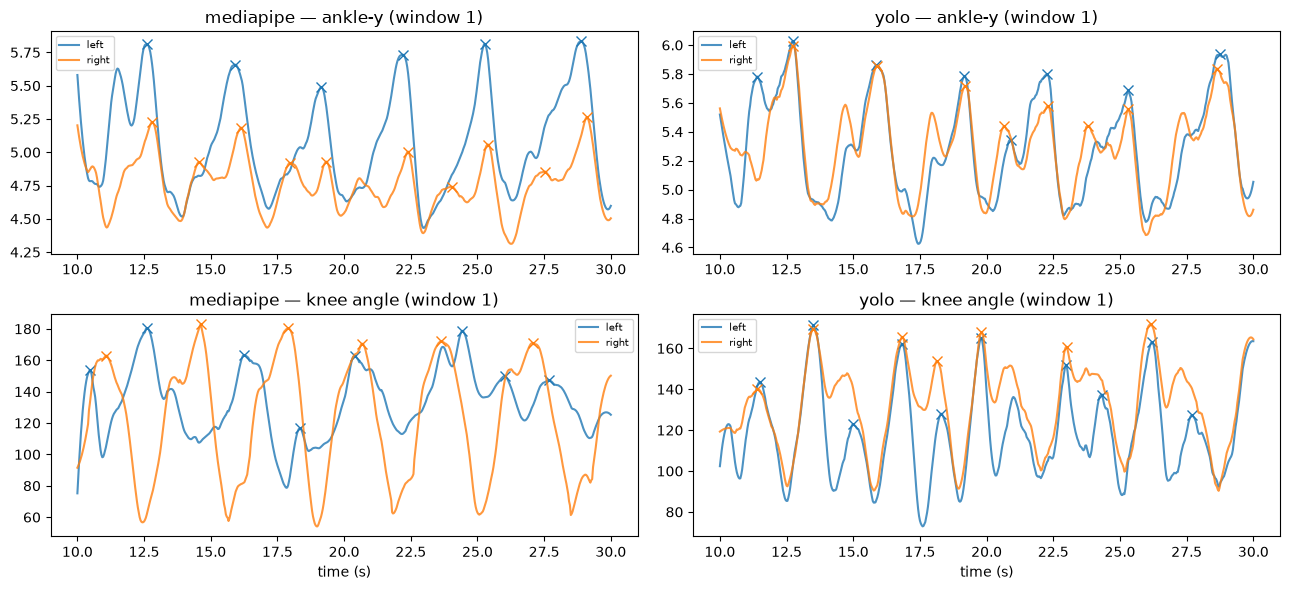

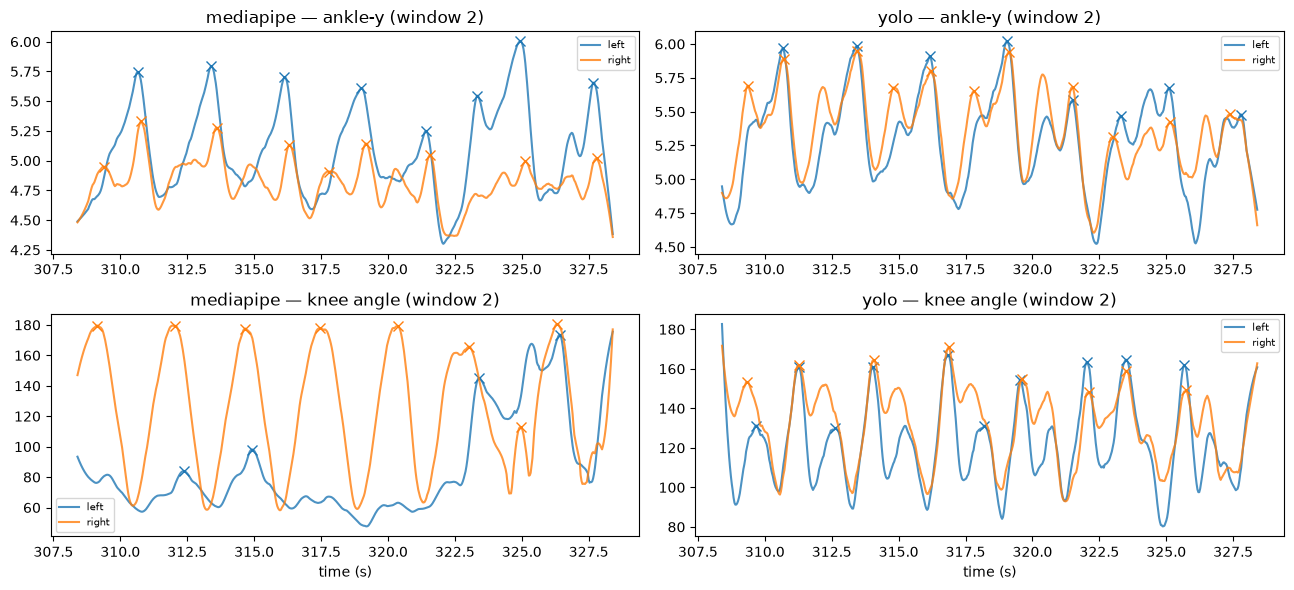

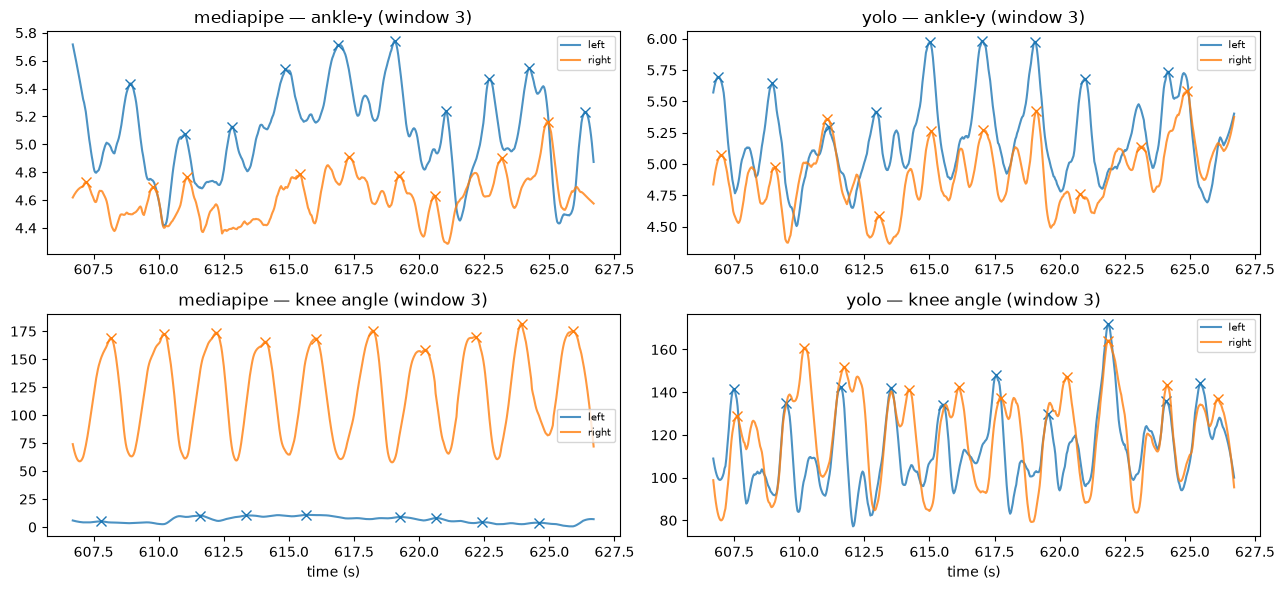

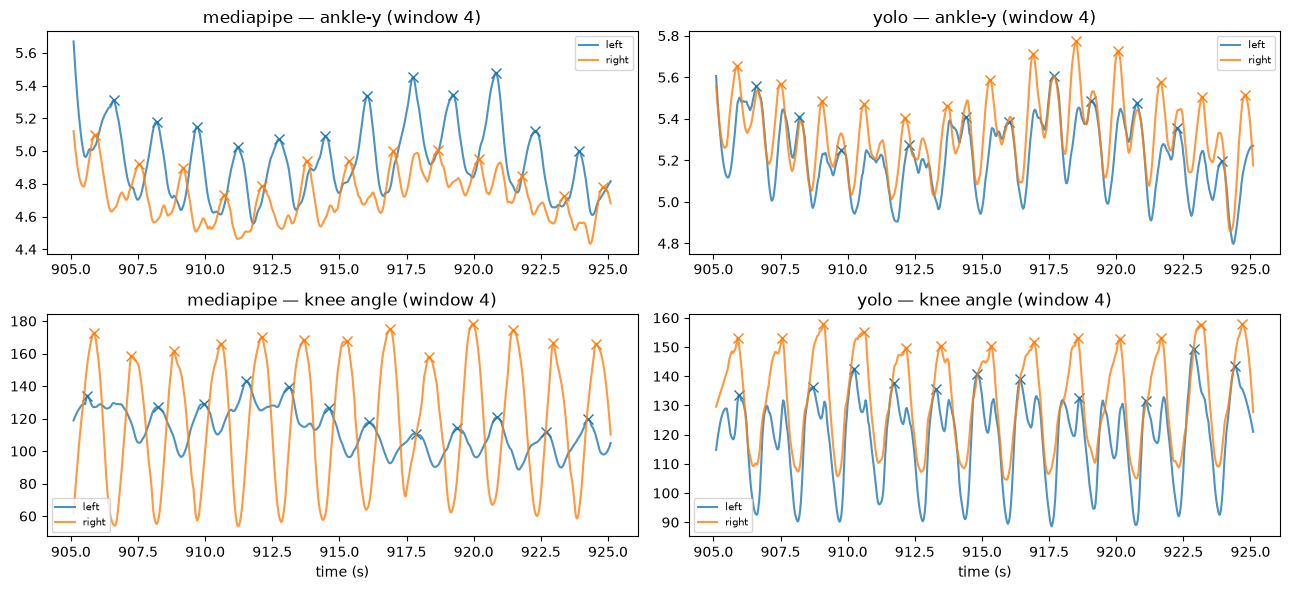

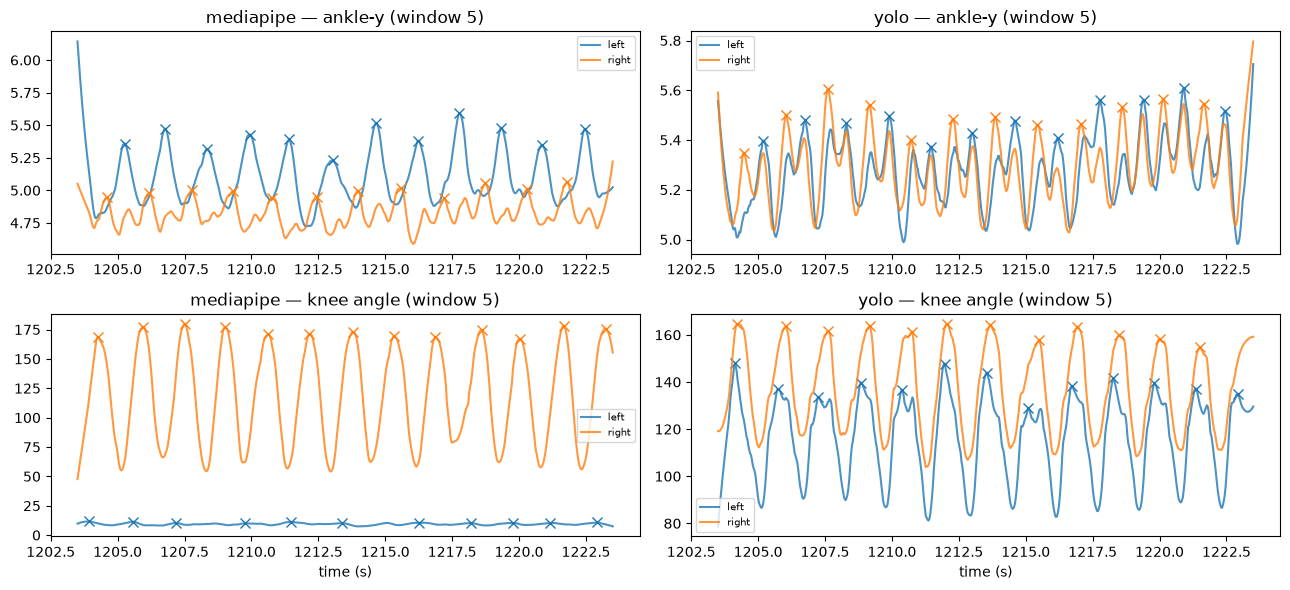

In [10]:
for i, res in enumerate(all_results):
    start, end = res["window"]
    fig, axes = plt.subplots(2, 2, figsize=(13, 6))
    for col, backend in enumerate(("mediapipe", "yolo")):
        r = res[backend]
        for leg, color in (("left", "tab:blue"), ("right", "tab:orange")):
            leg_r = r["per_leg"][leg]
            t = np.linspace(start, end, len(leg_r["ankle_signal"]))

            ax_ankle = axes[0, col]
            ax_ankle.plot(t, leg_r["ankle_signal"], color=color, alpha=0.8, label=f"{leg}")
            ax_ankle.plot(t[leg_r["ankle_peak_idx"]], leg_r["ankle_signal"][leg_r["ankle_peak_idx"]],
                          "x", color=color, markersize=7)
            ax_ankle.set_title(f"{backend} \u2014 ankle-y (window {i+1})")
            ax_ankle.legend(fontsize=7)

            ax_knee = axes[1, col]
            ax_knee.plot(t, leg_r["knee_signal"], color=color, alpha=0.8, label=f"{leg}")
            ax_knee.plot(t[leg_r["knee_peak_idx"]], leg_r["knee_signal"][leg_r["knee_peak_idx"]],
                        "x", color=color, markersize=7)
            ax_knee.set_title(f"{backend} \u2014 knee angle (window {i+1})")
            ax_knee.set_xlabel("time (s)")
            ax_knee.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

## 8. Full comparison table — all methods, both backends, both legs

In [11]:
header = (f"{'Window':<13}{'Backend':<11}{'Leg':<7}{'AnklePeak':<11}{'AnkleZC':<9}"
          f"{'KneePeak':<10}{'KneeZC':<8}{'Autocorr':<10}{'Conf':<7}{'Manual':<7}")
print(header)
print("-" * len(header))

for i, res in enumerate(all_results):
    start, end = res["window"]
    label = f"{fmt_time(start)}-{fmt_time(end)}"
    gt = GROUND_TRUTH.get(i)
    for backend in ("mediapipe", "yolo"):
        r = res[backend]
        for leg in ("left", "right"):
            lr = r["per_leg"][leg]
            manual = gt[leg] if gt else "-"
            print(f"{label:<13}{backend:<11}{leg:<7}{lr['ankle_peak_count']:<11}"
                  f"{lr['ankle_zc_count']:<9}{lr['knee_peak_count']:<10}{lr['knee_zc_count']:<8}"
                  f"{lr['autocorr_count']:<10.1f}{lr['mean_confidence']:<7.2f}{str(manual):<7}")
    print("-" * len(header))

print("\nNear-leg + zero-crossing method (Method 4) \u2014 estimated TOTAL steps per window:\n")
print(f"{'Window':<13}{'Backend':<11}{'NearLeg':<9}{'NearLegZC':<11}{'EstTotal':<10}{'Manual Total':<14}")
print("-" * 70)
for i, res in enumerate(all_results):
    start, end = res["window"]
    label = f"{fmt_time(start)}-{fmt_time(end)}"
    gt = GROUND_TRUTH.get(i)
    manual_total = (gt["left"] + gt["right"]) if gt else "-"
    for backend in ("mediapipe", "yolo"):
        r = res[backend]
        print(f"{label:<13}{backend:<11}{r['near_leg']:<9}{r['near_leg_zc_count']:<11}"
              f"{r['near_leg_estimated_total']:<10}{str(manual_total):<14}")
    print("-" * 70)

Window       Backend    Leg    AnklePeak  AnkleZC  KneePeak  KneeZC  Autocorr  Conf   Manual 
---------------------------------------------------------------------------------------------
00:10-00:30  mediapipe  left   6          6        8         6       6.2       0.76   7      
00:10-00:30  mediapipe  right  10         8        6         7       6.2       0.96   7      
00:10-00:30  yolo       left   8          6        10        11      6.2       0.96   7      
00:10-00:30  yolo       right  8          7        7         8       6.2       0.99   7      
---------------------------------------------------------------------------------------------
05:08-05:28  mediapipe  left   8          7        4         3       3.6       0.77   10     
05:08-05:28  mediapipe  right  9          9        8         7       7.3       0.96   10     
05:08-05:28  yolo       left   8          7        10        12      7.3       0.96   10     
05:08-05:28  yolo       right  11         7        8        

## How to read this

- **`Conf` column** (mean landmark confidence for that leg) is the key diagnostic: a low
  number confirms occlusion is happening for that leg in that window/backend. Compare left
  vs right — the lower one is the occluded/far leg, and its counts are the least trustworthy.
- **AnkleZC vs AnklePeak** on the same leg: if zero-crossing gives a cleaner, more plausible
  number than peak detection, that confirms the peak detector was being fooled by occlusion
  noise (fragmented peaks), which zero-crossing is more forgiving of.
- **KneePeak / KneeZC vs Ankle methods**: if the knee-angle signal (3-point geometry) gives
  a more stable count than the single-point ankle signal, that confirms angle is more robust
  to occlusion for your camera setup — use knee-angle going forward.
- **Near-leg method's `EstTotal`** is the one built specifically for your occlusion problem:
  it ignores the noisy far leg entirely and doubles the reliable near leg's count. Compare
  this directly against `Manual Total` (your 7+7=14 for window 1) — this is likely your best
  single number to trust once validated.
- **MediaPipe vs YOLO**: whichever backend's near-leg confidence is consistently higher is
  the one detecting the visible leg more reliably on your footage — prefer that backend.